# 02. 저변동성 포트폴리오 위험조정 수익 우위 검증

S&P500 유니버스에서 변동성 기준 분위 포트폴리오를 구성하고  
저변동성(Q1)이 고변동성(Q5) 대비 위험조정 수익이 높은지 검증한다.

## 분석 섹션
분석 기간 : 2010~2025년 (메인)  
| 섹션 | 목적 |
|---|---|
| 1 | 메인 분석 + Q1-Q5 스프레드 |
| 1-a | 강세장(2010~2015) 제외 구간 (2016~2025)|
| 1-b | 금융위기(GFC) 포함 전체 기간 (2005~2025) |
| 2 | 상하위 30% 분류 기준 성과 |
| 3 | 변동성-시가총액 관계 (상관관계 검정) |
| 4 | 연도별 2-year 누적수익률 |
| 5 | CAPM 알파 검정 |

## 방법론
- **포트폴리오 정렬**: 매월 말 vol_252d 기준 5분위 정렬 → 동일가중 수익률
- **Look-ahead bias 방지**: 당월 말 변동성으로 분류 → 다음 달 수익률 측정
- **생존편향 완화**: sp500_membership 기반 해당 월 편입 종목만 포함

In [346]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import io
import re
import zipfile
import requests
import platform
from pathlib import Path
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / 'data'
OUT_DIR   = BASE_DIR / 'outputs' / '02b_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PATH = DATA_DIR / 'monthly_panel.csv'
assert PANEL_PATH.exists(), '01_DataCollection.ipynb 먼저 실행하세요'

monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
monthly_df = monthly_df.set_index(['date', 'ticker'])

print(f'패널 로드: {monthly_df.shape}')
print(f'기간: {monthly_df.index.get_level_values("date").min().date()} ~ {monthly_df.index.get_level_values("date").max().date()}')
print(f'종목 수: {monthly_df.index.get_level_values("ticker").nunique()}')

패널 로드: (103878, 13)
기간: 2005-01-31 ~ 2025-12-31
종목 수: 617


=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===

월별 종목 수 요약:
  평균: 412개  |  최소: 332개  |  최대: 498개

[연도별 평균 종목 수]
  2005: 333개
  2006: 339개
  2007: 343개
  2008: 350개
  2009: 355개
  2010: 357개
  2011: 363개
  2012: 375개
  2013: 388개
  2014: 395개
  2015: 406개
  2016: 427개
  2017: 441개
  2018: 446개
  2019: 451개
  2020: 462개
  2021: 469개
  2022: 477개
  2023: 486개
  2024: 489개
  2025: 494개

[샘플 월 편입 종목 예시]
  2005-01-31: 332종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2010-01-31: 355종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2015-01-31: 398종목  → 예시: ['A', 'AA', 'AAPL', 'ABBV', 'ABT']
  2020-01-31: 458종목  → 예시: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV']
  2025-12-31: 498종목  → 예시: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']


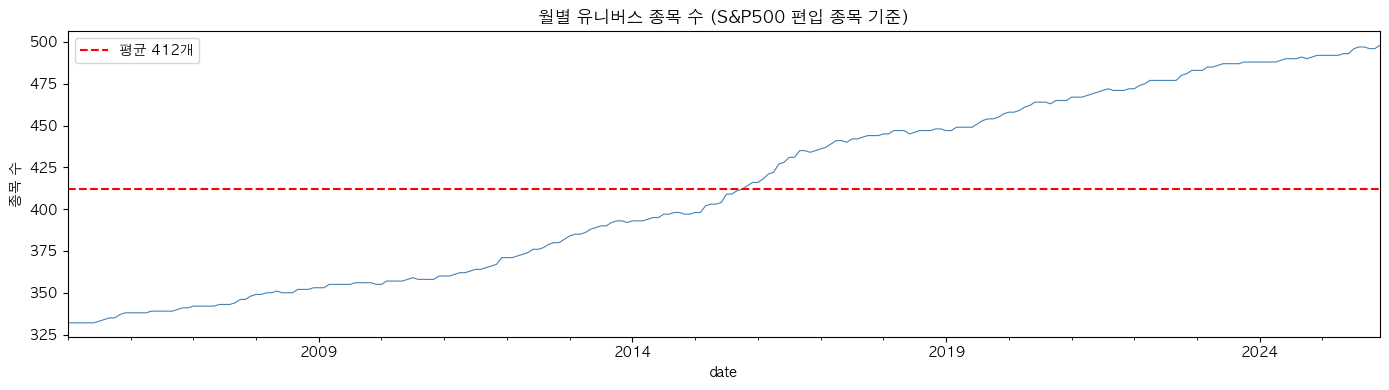

In [347]:
# ── 멤버십 필터링 검증: 실제로 당시 S&P500 편입 종목만 포함되는지 ──
print("=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===\n")

monthly_counts = monthly_df.groupby(level='date').size()
print(f"월별 종목 수 요약:")
print(f"  평균: {monthly_counts.mean():.0f}개  |  최소: {monthly_counts.min()}개  |  최대: {monthly_counts.max()}개\n")

print("[연도별 평균 종목 수]")
yearly = monthly_counts.groupby(monthly_counts.index.year).mean().astype(int)
for yr, cnt in yearly.items():
    print(f"  {yr}: {cnt}개")

print("\n[샘플 월 편입 종목 예시]")
sample_dates = monthly_counts.index[[0, 60, 120, 180, -1]]
for d in sample_dates:
    tickers = monthly_df.loc[d].index.tolist()
    print(f"  {d.date()}: {len(tickers)}종목  → 예시: {tickers[:5]}")

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.axhline(monthly_counts.mean(), color='red', linestyle='--',
           label=f'평균 {monthly_counts.mean():.0f}개')
ax.set_title('월별 유니버스 종목 수 (S&P500 편입 종목 기준)')
ax.set_ylabel('종목 수')
ax.legend()
plt.tight_layout()
plt.show()

=== 기술통계 ===
            ret_1m    beta_252d     vol_252d
count  103844.0000  103280.0000  103280.0000
mean        0.0106       1.0097       0.3097
std         0.0910       0.4095       0.1707
min        -0.8435      -1.6256       0.0905
1%         -0.2273       0.1133       0.1300
5%         -0.1253       0.3792       0.1536
25%        -0.0370       0.7493       0.2072
50%         0.0111       0.9878       0.2662
75%         0.0569       1.2422       0.3597
95%         0.1447       1.7100       0.5953
99%         0.2552       2.1509       0.9657
max         2.4498       3.9243       2.8059

=== 극단값 확인 ===

[ret_1m]
  min=-0.8435  max=2.4498
  1%=-0.2273  99%=0.2552
  1~99% 밖 관측 수: 2078개 (2.0%)

[beta_252d]
  min=-1.6256  max=3.9243
  1%=0.1133  99%=2.1509
  1~99% 밖 관측 수: 2066개 (2.0%)

[vol_252d]
  min=0.0905  max=2.8059
  1%=0.1300  99%=0.9657
  1~99% 밖 관측 수: 2066개 (2.0%)

=== ret_1m 최대값 상위 10개 ===
date        ticker
2009-08-31  AIG       2.449772
2010-02-28  GR        2.333333
2020-0

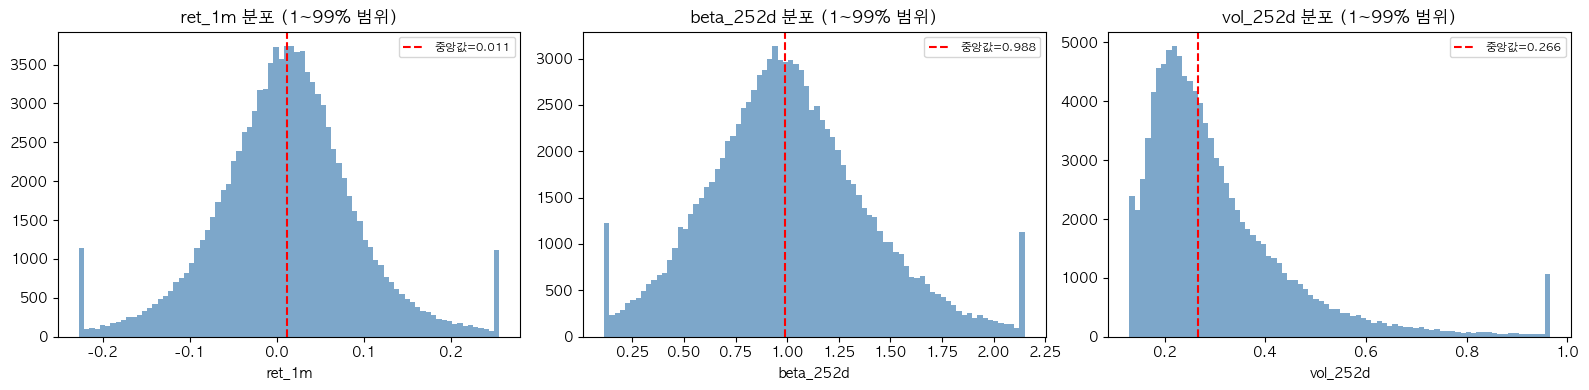

In [348]:
# ── 주요 변수 분포 확인 (포트폴리오 정렬 전) ─────────────────
cols = ['ret_1m', 'beta_252d', 'vol_252d']

print("=== 기술통계 ===")
print(monthly_df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).round(4))

print("\n=== 극단값 확인 ===")
for col in cols:
    s = monthly_df[col].dropna()
    print(f"\n[{col}]")
    print(f"  min={s.min():.4f}  max={s.max():.4f}")
    print(f"  1%={s.quantile(0.01):.4f}  99%={s.quantile(0.99):.4f}")
    n_extreme = ((s < s.quantile(0.01)) | (s > s.quantile(0.99))).sum()
    print(f"  1~99% 밖 관측 수: {n_extreme}개 ({n_extreme/len(s):.1%})")

# ── 극단값 원인 확인: ret_1m 상위/하위 10개 ───────────────
print("\n=== ret_1m 최대값 상위 10개 ===")
print(monthly_df['ret_1m'].nlargest(10))

print("\n=== ret_1m 최솟값 하위 10개 ===")
print(monthly_df['ret_1m'].nsmallest(10))

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cols):
    s = monthly_df[col].dropna()
    p1, p99 = s.quantile(0.01), s.quantile(0.99)
    ax.hist(s.clip(p1, p99), bins=80, color='steelblue', alpha=0.7)
    ax.set_title(f'{col} 분포 (1~99% 범위)')
    ax.set_xlabel(col)
    ax.axvline(s.median(), color='red', linestyle='--', label=f'중앙값={s.median():.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 포트폴리오 정렬 (Portfolio Sort)

## 방법
매월 말 시점에 `beta_252d` / `vol_252d` 기준으로 5분위 정렬:
- **Q1**: 저베타 (저위험) / 저변동
- **Q5**: 고베타 (고위험) / 고변동

각 분위에서 동일가중(Equal-Weight) 포트폴리오를 구성하고 다음 달 수익률(`ret_1m`)을 측정한다.

**Look-ahead bias 방지**: 당월 말 beta로 분류 → 다음 달 수익률 측정 (이미 `ret_1m`에 반영)

In [349]:
def portfolio_sort(df, sort_col, ret_col='ret_1m', n_quantiles=5):
    """
    매월 sort_col 기준으로 n_quantiles 분위 포트폴리오 구성.
    각 분위의 동일가중 수익률 반환.
    """
    results = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < n_quantiles * 5:  # 분위당 최소 5종목
            continue
        try:
            labels = list(range(1, n_quantiles + 1))
            valid['quintile'] = pd.qcut(valid[sort_col], n_quantiles,
                                        labels=labels, duplicates='drop')
            port_ret = valid.groupby('quintile')[ret_col].mean()
            port_ret.name = date
            results.append(port_ret)
        except Exception as e:
            print(f"  [{date.date()}] 스킵: {e}")
            continue
    return pd.DataFrame(results)


# 베타 기준 포트폴리오
beta_ports = portfolio_sort(monthly_df, 'beta_252d')
# 변동성 기준 포트폴리오
vol_ports  = portfolio_sort(monthly_df, 'vol_252d')

# 무위험수익률 (월별)
rf_monthly = monthly_df['rf_1m'].groupby(level='date').first()

print(f'베타 포트폴리오: {beta_ports.shape[0]}개월 × {beta_ports.shape[1]}분위')
print(f'변동성 포트폴리오: {vol_ports.shape[0]}개월 × {vol_ports.shape[1]}분위')

베타 포트폴리오: 252개월 × 5분위
변동성 포트폴리오: 252개월 × 5분위


In [350]:
# duplicates로 제거되는 분위 수가 있는지 확인
print(beta_ports.isna().sum())
print(vol_ports.isna().sum())

quintile
1    0
2    0
3    0
4    0
5    0
dtype: int64
quintile
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [351]:
# ── 전역 변수 및 함수 정의 ────────────────────────────────────
ANN     = np.sqrt(12)
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
labels  = ['Q1 (저위험)', 'Q2', 'Q3', 'Q4', 'Q5 (고위험)']
spy_monthly = monthly_df['spy_ret'].groupby(level='date').first()

def nw_ttest(series):
    """시계열 평균의 Newey-West HAC t-검정 (H0: mean = 0)"""
    s = series.dropna().values
    n = len(s)
    lags = int(4 * (n / 100) ** (2/9))
    res = sm.OLS(s, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.tvalues[0], res.pvalues[0]

def performance_summary(port_df, rf_series, label='베타'):
    rf_aligned = rf_series.reindex(port_df.index)
    rows = []
    for q in port_df.columns:
        r      = port_df[q].dropna()
        rf     = rf_aligned.reindex(r.index)
        excess = r - rf
        cum    = (1 + r).cumprod()
        mdd    = (cum / cum.cummax() - 1).min()
        rows.append({
            f'{label} 분위': f'Q{q}',
            '연환산 수익률': f'{r.mean()*12:.2%}',
            '연환산 변동성': f'{r.std()*ANN:.2%}',
            'Sharpe Ratio':  f'{excess.mean()/excess.std()*ANN:.3f}',
            'MDD':           f'{mdd:.2%}',
            '누적 수익률':    f'{(1+r).prod()-1:.2%}',
        })
    return pd.DataFrame(rows).set_index(f'{label} 분위')


print('전역 변수 및 함수 정의 완료')
print(f'  spy_monthly: {spy_monthly.shape[0]}개월 / colors, labels, ANN, nw_ttest, performance_summary')


전역 변수 및 함수 정의 완료
  spy_monthly: 252개월 / colors, labels, ANN, nw_ttest, performance_summary


## 1. 2010~2025 (메인 분석 구간)

=== [2010~2025] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio      MDD   누적 수익률
베타 분위                                               
Q1     11.97%  10.90%        0.970  -13.60%  512.60%
Q2     13.42%  13.15%        0.915  -17.82%  638.95%
Q3     13.88%  16.02%        0.781  -25.74%  643.43%
Q4     14.60%  19.12%        0.693  -31.68%  663.45%
Q5     15.53%  25.85%        0.549  -46.26%  589.29%

=== [2010~2025] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio      MDD   누적 수익률
변동성 분위                                               
Q1      14.28%  11.12%        1.159  -15.25%  779.53%
Q2      13.23%  13.36%        0.887  -18.52%  613.22%
Q3      13.79%  15.64%        0.795  -23.55%  639.61%
Q4      13.18%  18.72%        0.632  -31.11%  517.74%
Q5      14.92%  25.08%        0.541  -46.80%  542.61%


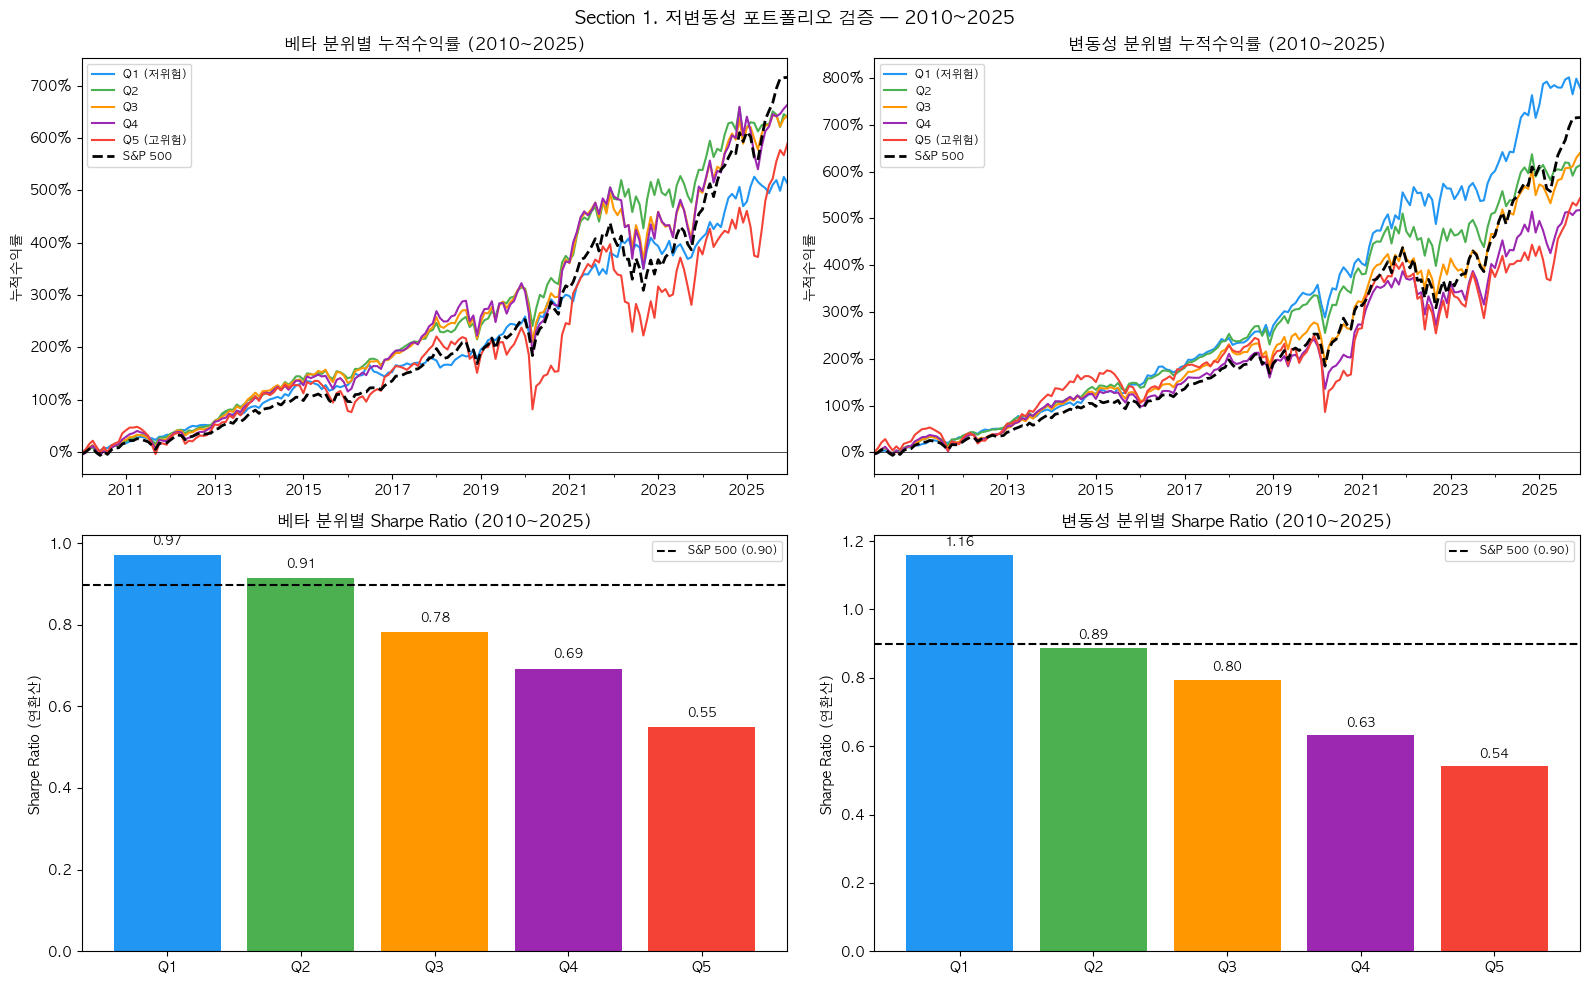

In [352]:
# ── Section 1. 2010~2025 (메인 분석 구간) ───────────────────────
START_BT = '2010-01-01'
END_BT   = '2025-12-31'

df_bt         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_BT) &
    (monthly_df.index.get_level_values('date') <= END_BT)
]
beta_ports_bt = portfolio_sort(df_bt, 'beta_252d')
vol_ports_bt  = portfolio_sort(df_bt, 'vol_252d')
rf_bt         = rf_monthly[(rf_monthly.index >= START_BT) & (rf_monthly.index <= END_BT)]

print('=== [2010~2025] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_bt, rf_bt, '베타'))
print('\n=== [2010~2025] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_bt, rf_bt, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 1. 저변동성 포트폴리오 검증 — 2010~2025', fontsize=13, fontweight='bold')

rf_b_bt  = rf_bt.reindex(beta_ports_bt.index)
rf_v_bt2 = rf_bt.reindex(vol_ports_bt.index)
spy_bt   = spy_monthly[(spy_monthly.index >= START_BT) & (spy_monthly.index <= END_BT)]
spy_cum_bt = (1 + spy_bt).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_bt, '베타 분위별 누적수익률 (2010~2025)'),
    (axes[0, 1], vol_ports_bt,  '변동성 분위별 누적수익률 (2010~2025)'),
]:
    for i, q in enumerate(ports.columns):
        (1 + ports[q].dropna()).cumprod().sub(1).plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_bt.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                          color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_bt, rf_b_bt,  '베타 분위별 Sharpe Ratio (2010~2025)'),
    (axes[1, 1], vol_ports_bt,  rf_v_bt2, '변동성 분위별 Sharpe Ratio (2010~2025)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_bt.reindex(ports.index) - rf_a).mean() / \
              (spy_bt.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2010.png', dpi=150, bbox_inches='tight')
plt.show()

### a. 2016~2025 (강세장 제거)

=== [2016~2025] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio      MDD   누적 수익률
베타 분위                                               
Q1     10.71%  11.99%        0.714  -13.60%  170.84%
Q2     11.94%  13.94%        0.702  -17.82%  198.30%
Q3     12.55%  16.88%        0.618  -25.74%  202.73%
Q4     13.94%  20.05%        0.589  -31.68%  227.69%
Q5     16.21%  27.68%        0.509  -46.26%  239.08%

=== [2016~2025] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio      MDD   누적 수익률
변동성 분위                                               
Q1      13.58%  12.12%        0.942  -15.25%  259.09%
Q2      11.62%  14.20%        0.668  -18.52%  187.72%
Q3      13.36%  16.38%        0.686  -23.55%  230.72%
Q4      12.46%  19.37%        0.533  -31.11%  186.76%
Q5      14.33%  26.98%        0.453  -46.80%  185.96%


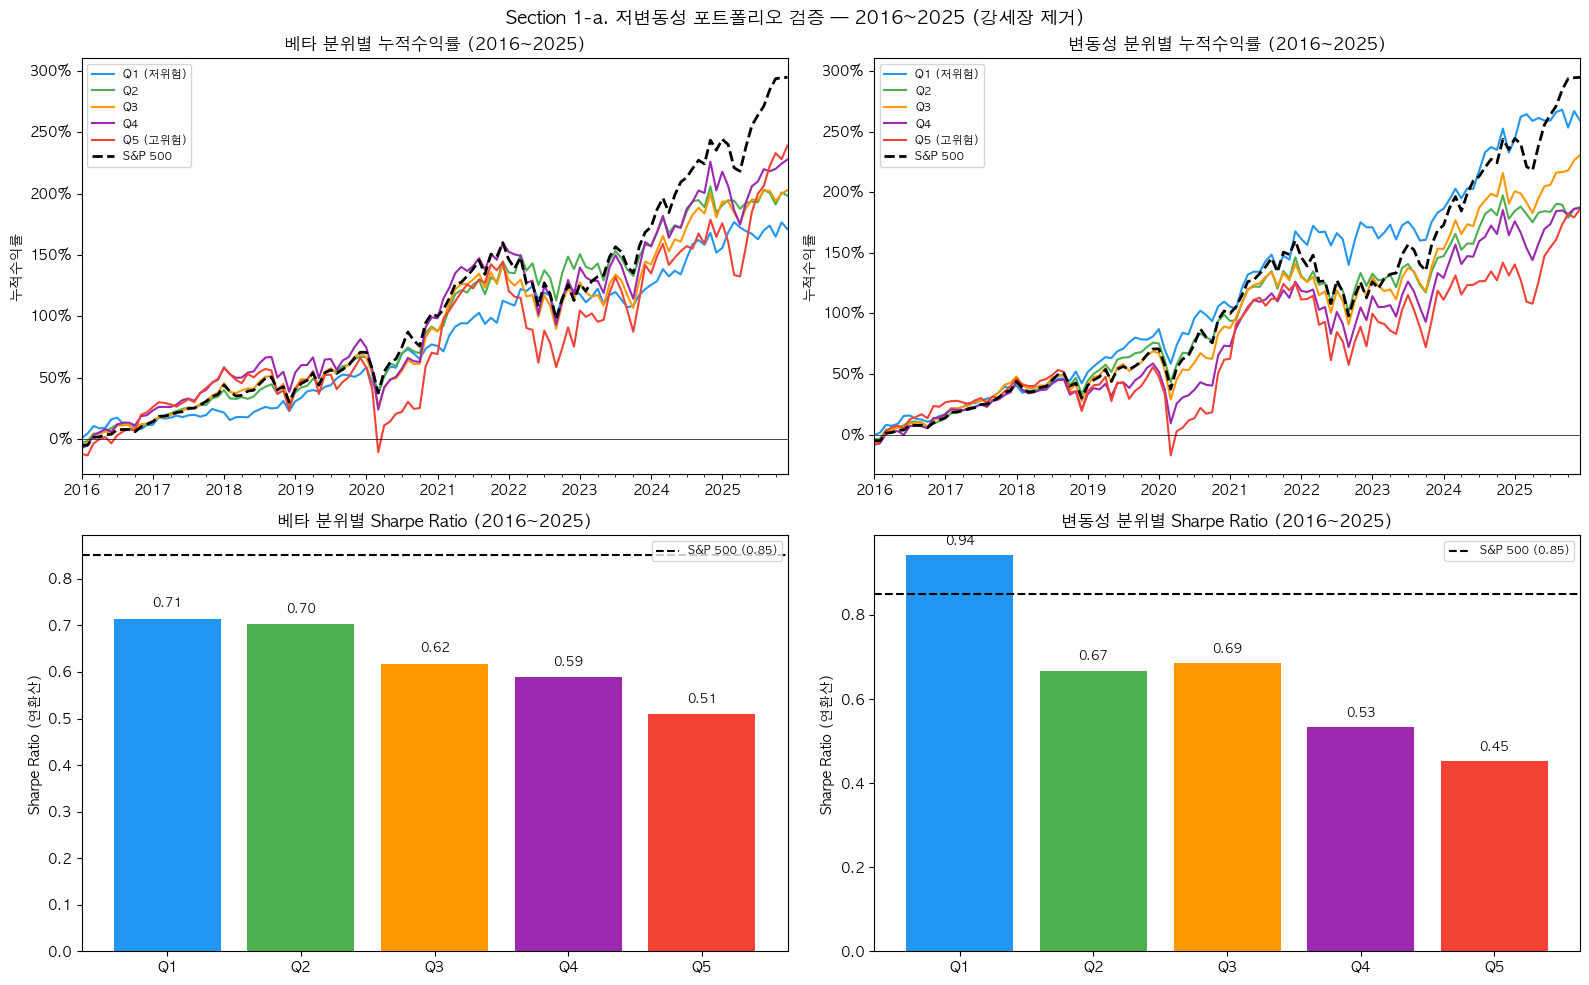

In [353]:
# ── Section 1-a. 2016~2025 (강세장 제거) ───────────────────────────
# 2010~2015: GFC 이후 QE 주도 강세장 — 고변동성 종목 강한 반등 구간
# 2015년 이전 제외하면 저변동 우위가 더 뚜렷하게 나타나는지 확인
START_R = '2016-01-01'
END_R   = '2025-12-31'

df_r         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_R) &
    (monthly_df.index.get_level_values('date') <= END_R)
]
beta_ports_r = portfolio_sort(df_r, 'beta_252d')
vol_ports_r  = portfolio_sort(df_r, 'vol_252d')
rf_r         = rf_monthly[(rf_monthly.index >= START_R) & (rf_monthly.index <= END_R)]

print('=== [2016~2025] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_r, rf_r, '베타'))
print('\n=== [2016~2025] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_r, rf_r, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 1-a. 저변동성 포트폴리오 검증 — 2016~2025 (강세장 제거)', fontsize=13, fontweight='bold')

rf_b_r  = rf_r.reindex(beta_ports_r.index)
rf_v_r  = rf_r.reindex(vol_ports_r.index)
spy_r   = spy_monthly[(spy_monthly.index >= START_R) & (spy_monthly.index <= END_R)]
spy_cum_r = (1 + spy_r).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_r, '베타 분위별 누적수익률 (2016~2025)'),
    (axes[0, 1], vol_ports_r,  '변동성 분위별 누적수익률 (2016~2025)'),
]:
    for i, q in enumerate(ports.columns):
        cum = (1 + ports[q].dropna()).cumprod() - 1
        cum.plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_r.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                         color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_r, rf_b_r, '베타 분위별 Sharpe Ratio (2016~2025)'),
    (axes[1, 1], vol_ports_r,  rf_v_r, '변동성 분위별 Sharpe Ratio (2016~2025)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_r.reindex(ports.index) - rf_a).mean() / \
              (spy_r.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2016.png', dpi=150, bbox_inches='tight')
plt.show()

### b. 2005~2025 (금융위기 포함 전체 기간)

=== [2005~2025] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio      MDD    누적 수익률
베타 분위                                                
Q1     10.33%  11.18%        0.773  -36.99%   661.18%
Q2     11.76%  13.50%        0.745  -41.41%   864.10%
Q3     12.53%  17.22%        0.630  -51.04%   903.65%
Q4     13.78%  20.55%        0.589  -55.56%  1046.29%
Q5     14.62%  27.24%        0.476  -63.72%   869.51%

=== [2005~2025] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio      MDD    누적 수익률
변동성 분위                                                
Q1      11.97%  11.16%        0.920  -32.85%   971.94%
Q2      11.31%  13.84%        0.696  -43.03%   770.21%
Q3      12.28%  16.84%        0.630  -50.69%   865.54%
Q4      12.17%  19.83%        0.529  -54.19%   743.35%
Q5      15.27%  27.15%        0.501  -65.91%  1018.24%


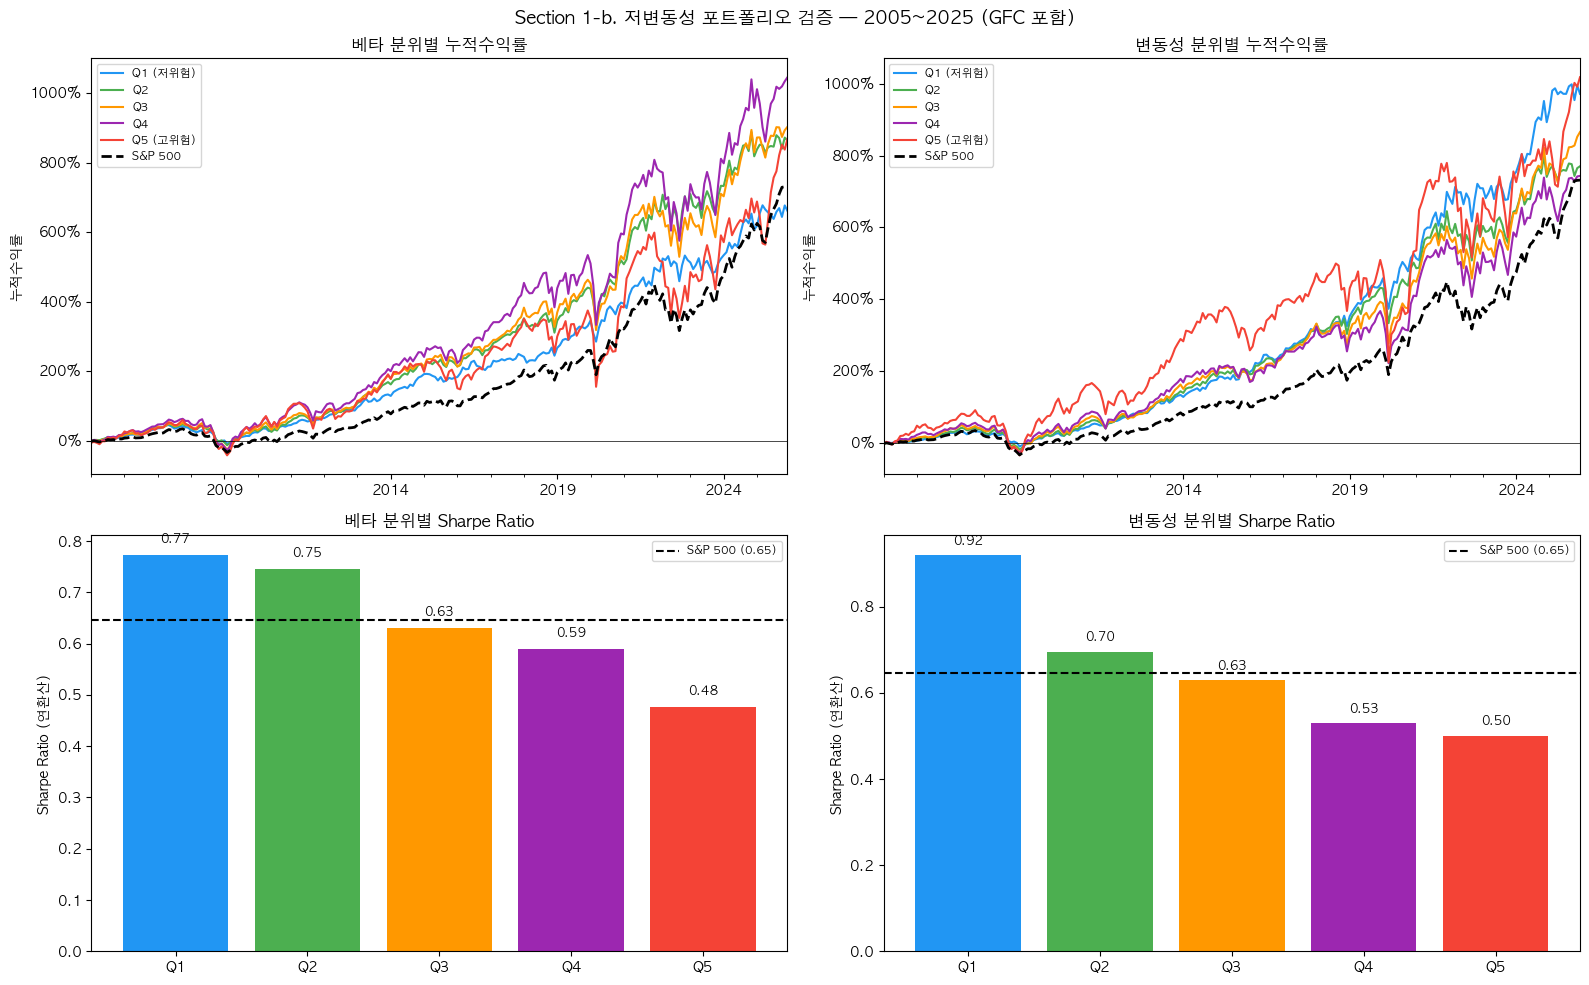

In [354]:
# ── Section 1-b. 2005~2025 (금융위기 포함 전체 기간) ───────────────
print('=== [2005~2025] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports, rf_monthly, '베타'))
print('\n=== [2005~2025] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports, rf_monthly, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 1-b. 저변동성 포트폴리오 검증 — 2005~2025 (GFC 포함)', fontsize=13, fontweight='bold')

spy_cum     = (1 + spy_monthly).cumprod() - 1
rf_a_beta   = rf_monthly.reindex(beta_ports.index)
rf_a_vol    = rf_monthly.reindex(vol_ports.index)

for ax, ports, rf_a, title_cum in [
    (axes[0, 0], beta_ports, rf_a_beta, '베타 분위별 누적수익률'),
    (axes[0, 1], vol_ports,  rf_a_vol,  '변동성 분위별 누적수익률'),
]:
    for i, q in enumerate(ports.columns):
        (1 + ports[q].dropna()).cumprod().sub(1).plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum.reindex(ports.index).plot(ax=ax, label='S&P 500', color='black', linestyle='--', linewidth=2)
    ax.set_title(title_cum)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title_sr in [
    (axes[1, 0], beta_ports, rf_a_beta, '베타 분위별 Sharpe Ratio'),
    (axes[1, 1], vol_ports,  rf_a_vol,  '변동성 분위별 Sharpe Ratio'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN for q in ports.columns]
    spy_sr  = (spy_monthly.reindex(ports.index) - rf_a).mean() / \
              (spy_monthly.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5, label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title_sr)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 30%/30% 분류 기준 성과

=== [30%/30% 분류 기준 — 2010~2025] ===
          그룹 연환산 수익률 연환산 변동성 Sharpe     MDD  누적 수익률
저변동 (하위 30%)  13.94%  11.45%  1.096 -16.19% 728.63%
고변동 (상위 30%)  14.53%  23.13%  0.570 -42.38% 555.87%


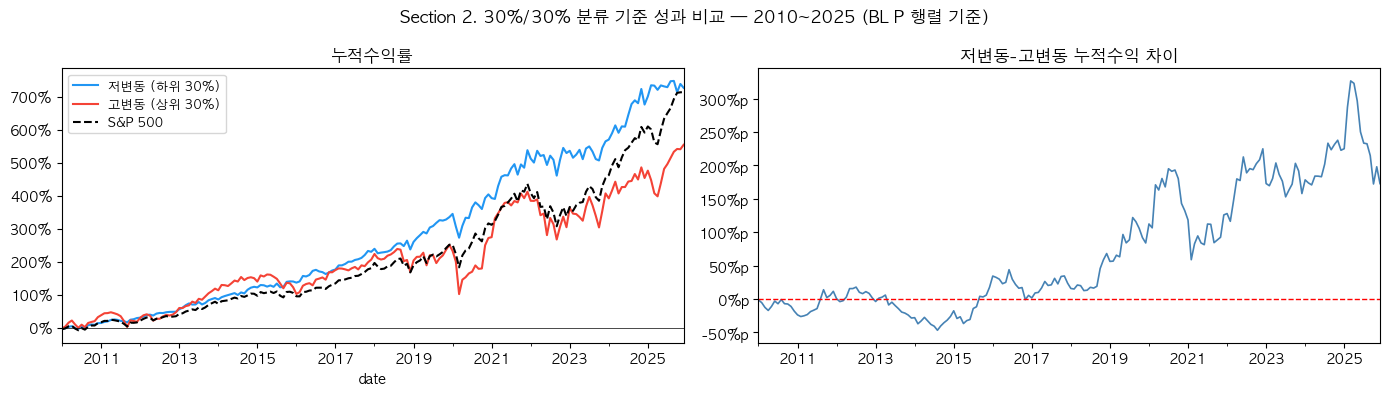

In [355]:
# ── Section 2. 30%/30% 분류 기준 성과 ──
LOW_PCTILE  = 0.30
HIGH_PCTILE = 0.70

def portfolio_30(df, sort_col='vol_252d', ret_col='ret_1m'):
    low_rets, high_rets, dates = [], [], []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < 20:
            continue
        q_low  = valid[sort_col].quantile(LOW_PCTILE)
        q_high = valid[sort_col].quantile(HIGH_PCTILE)
        low_rets.append(valid[valid[sort_col] <= q_low][ret_col].mean())
        high_rets.append(valid[valid[sort_col] >= q_high][ret_col].mean())
        dates.append(date)
    return pd.Series(low_rets, index=pd.DatetimeIndex(dates)), \
           pd.Series(high_rets, index=pd.DatetimeIndex(dates))

low_30, high_30 = portfolio_30(df_bt)
rf_30 = rf_bt.reindex(low_30.index)

def _stats(r, rf, label):
    exc = r - rf
    cum = (1 + r).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'그룹': label, '연환산 수익률': f'{r.mean()*12:.2%}',
            '연환산 변동성': f'{r.std()*ANN:.2%}',
            'Sharpe': f'{exc.mean()/exc.std()*ANN:.3f}',
            'MDD': f'{mdd:.2%}',
            '누적 수익률': f'{(1+r).prod()-1:.2%}'}

print('=== [30%/30% 분류 기준 — 2010~2025] ===')
print(pd.DataFrame([_stats(low_30, rf_30, '저변동 (하위 30%)'),
                    _stats(high_30, rf_30, '고변동 (상위 30%)')]).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Section 2. 30%/30% 분류 기준 성과 비교 — 2010~2025 (BL P 행렬 기준)', fontsize=12)
ax = axes[0]
(1+low_30).cumprod().sub(1).plot(ax=ax, label='저변동 (하위 30%)', color='#2196F3', linewidth=1.5)
(1+high_30).cumprod().sub(1).plot(ax=ax, label='고변동 (상위 30%)', color='#F44336', linewidth=1.5)
spy_cum_bt.plot(ax=ax, label='S&P 500', color='black', linestyle='--', linewidth=1.5)
ax.set_title('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=9)
((1 + low_30).cumprod() - 1 - ((1 + high_30).cumprod() - 1)).plot(ax=axes[1], color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('저변동-고변동 누적수익 차이')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:.0f}%p'))
plt.tight_layout()
plt.show()

임계값 민감도 분석 — 저변동/고변동 분류 기준 (2010~2025)
          저변동 Sharpe 고변동 Sharpe Sharpe 격차 저변동 MDD 고변동 MDD  MDD 격차
임계값                                                              
20% / 80%      1.159      0.542    +0.616  -15.3%  -46.8%  +31.6%
25% / 75%      1.135      0.552    +0.584  -15.5%  -43.8%  +28.3%
30% / 70%      1.096      0.570    +0.526  -16.2%  -42.4%  +26.2%
35% / 65%      1.061      0.576    +0.485  -16.6%  -40.5%  +23.9%
40% / 60%      1.042      0.588    +0.454  -16.7%  -39.0%  +22.3%

  Sharpe 격차 양수 & MDD 격차 양수 → 저변동 우위 확인
  → 임계값이 달라져도 방향이 일관되면 30% 선택 robust


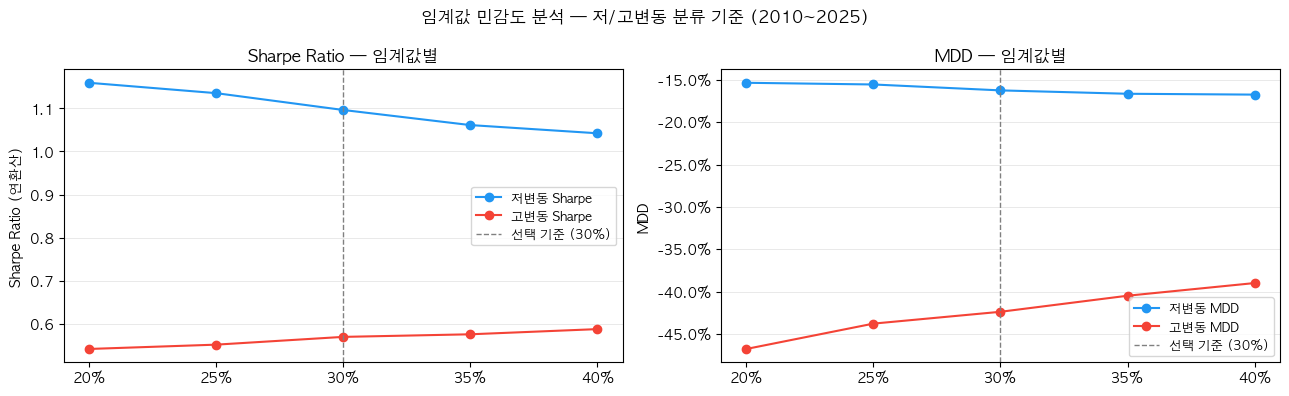

In [356]:
# ── 임계값 민감도 분석: 저변동 분류 기준이 30%여도 괜찮은가? ──────
# 20%~40% 범위에서 임계값을 바꿔가며 저변동 우위가 일관되게 유지되는지 확인
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40]

sens_rows = []
for pct in thresholds:
    low_rets, high_rets, dates = [], [], []
    for date, group in df_bt.groupby(level='date'):
        valid = group[['vol_252d', 'ret_1m']].dropna()
        if len(valid) < 20:
            continue
        q_low  = valid['vol_252d'].quantile(pct)
        q_high = valid['vol_252d'].quantile(1 - pct)
        low_rets.append(valid[valid['vol_252d'] <= q_low]['ret_1m'].mean())
        high_rets.append(valid[valid['vol_252d'] >= q_high]['ret_1m'].mean())
        dates.append(date)

    low_s  = pd.Series(low_rets,  index=pd.DatetimeIndex(dates))
    high_s = pd.Series(high_rets, index=pd.DatetimeIndex(dates))
    rf_s   = rf_bt.reindex(low_s.index)

    low_sr  = (low_s  - rf_s).mean() / (low_s  - rf_s).std() * ANN
    high_sr = (high_s - rf_s).mean() / (high_s - rf_s).std() * ANN

    low_cum  = (1 + low_s).cumprod()
    high_cum = (1 + high_s).cumprod()
    low_mdd  = (low_cum  / low_cum.cummax()  - 1).min()
    high_mdd = (high_cum / high_cum.cummax() - 1).min()

    sens_rows.append({
        '임계값':         f'{pct:.0%} / {1-pct:.0%}',
        '저변동 Sharpe':  f'{low_sr:.3f}',
        '고변동 Sharpe':  f'{high_sr:.3f}',
        'Sharpe 격차':    f'{low_sr - high_sr:+.3f}',
        '저변동 MDD':     f'{low_mdd:.1%}',
        '고변동 MDD':     f'{high_mdd:.1%}',
        'MDD 격차':       f'{low_mdd - high_mdd:+.1%}',
    })

sens_df = pd.DataFrame(sens_rows).set_index('임계값')
print('=' * 75)
print('임계값 민감도 분석 — 저변동/고변동 분류 기준 (2010~2025)')
print('=' * 75)
print(sens_df.to_string())
print()
print('  Sharpe 격차 양수 & MDD 격차 양수 → 저변동 우위 확인')
print('  → 임계값이 달라져도 방향이 일관되면 30% 선택 robust')

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('임계값 민감도 분석 — 저/고변동 분류 기준 (2010~2025)', fontsize=12)

x            = [f'{p:.0%}' for p in thresholds]
low_sr_vals  = [float(r['저변동 Sharpe']) for r in sens_rows]
high_sr_vals = [float(r['고변동 Sharpe']) for r in sens_rows]
low_mdd_vals = [float(r['저변동 MDD'].replace('%',''))/100 for r in sens_rows]
high_mdd_vals= [float(r['고변동 MDD'].replace('%',''))/100 for r in sens_rows]

ax = axes[0]
ax.plot(x, low_sr_vals,  marker='o', color='#2196F3', label='저변동 Sharpe')
ax.plot(x, high_sr_vals, marker='o', color='#F44336', label='고변동 Sharpe')
ax.axvline(x='30%', color='gray', linestyle='--', linewidth=1, label='선택 기준 (30%)')
ax.set_title('Sharpe Ratio — 임계값별')
ax.set_ylabel('Sharpe Ratio (연환산)')
ax.legend(fontsize=9)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

ax = axes[1]
ax.plot(x, low_mdd_vals,  marker='o', color='#2196F3', label='저변동 MDD')
ax.plot(x, high_mdd_vals, marker='o', color='#F44336', label='고변동 MDD')
ax.axvline(x='30%', color='gray', linestyle='--', linewidth=1, label='선택 기준 (30%)')
ax.set_title('MDD — 임계값별')
ax.set_ylabel('MDD')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()


## 3. 변동성-시가총액 관계

[변동성-시가총액 Spearman 상관관계 검정 — 2010~2025]
  월평균 ρ      : -0.272
  ρ 범위        : -0.425 ~ -0.082
  NW t-통계량   : -28.478  p-value: 2.22e-178
  해석          : 저변동성 ↔ 대형주 유의한 음의 상관 ✓
  → 시가총액 가중 Prior가 저변동 목적과 방향 일치 — Prior 선택 적절성 확인 ✓


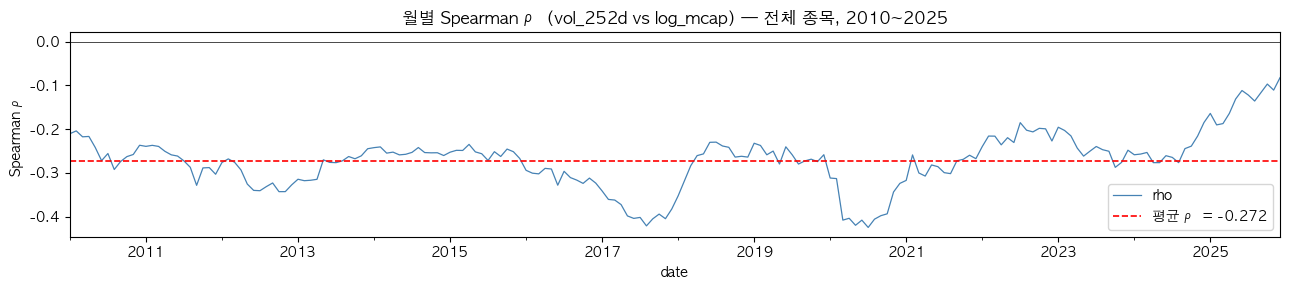

[하위/상위 30% 그룹별 평균 시가총액 순위 — 2010~2025]
  저변동 (하위 30%) 평균 순위: 0.417  (낮을수록 대형주)
  고변동 (상위 30%) 평균 순위: 0.599
  → 저변동이 대형주 성향 ✓


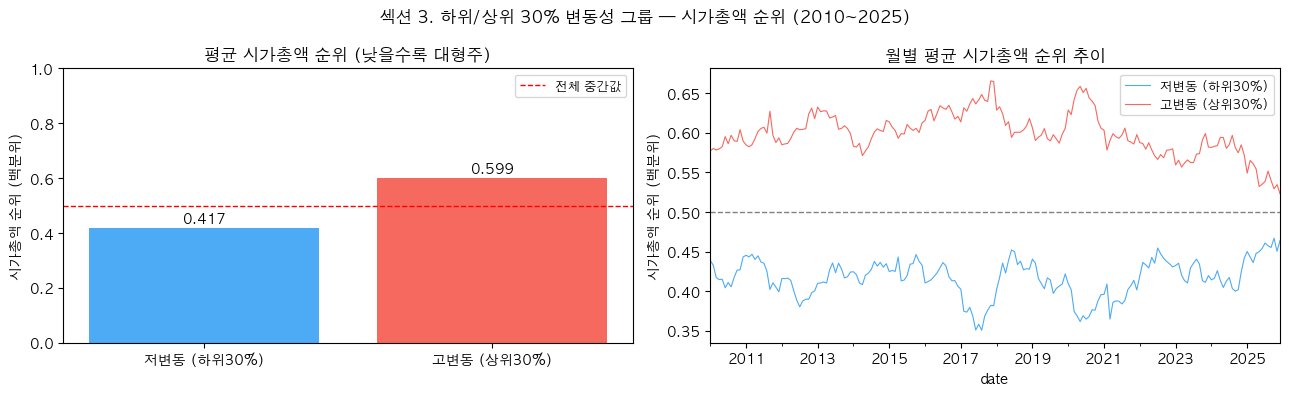

In [357]:
# ── Section 3. 변동성-시가총액 관계 (2010~2025 기준) ────────────
# 변동성 그룹별 시가총액 순위 비교 — 시가총액 가중 Prior 적절성 검증
# (안전 포트폴리오 목적 상 저변동 ≈ 대형주라면 Prior 선택이 목적과 일치)

# ── Step 1. Spearman 상관관계 검정: 전체 종목 기준 (2010~2025) ──
monthly_corr = []
for date, group in df_bt.groupby(level='date'):
    valid = group[['vol_252d', 'log_mcap']].dropna()
    if len(valid) < 20:
        continue
    rho, _ = stats.spearmanr(valid['vol_252d'], valid['log_mcap'])
    monthly_corr.append({'date': date, 'rho': rho})

corr_df    = pd.DataFrame(monthly_corr).set_index('date')
mean_rho   = corr_df['rho'].mean()
t_stat, p_val = nw_ttest(corr_df['rho'])

print('=' * 55)
print('[변동성-시가총액 Spearman 상관관계 검정 — 2010~2025]')
print('=' * 55)
print(f'  월평균 ρ      : {mean_rho:.3f}')
print(f'  ρ 범위        : {corr_df["rho"].min():.3f} ~ {corr_df["rho"].max():.3f}')
print(f'  NW t-통계량   : {t_stat:.3f}  p-value: {p_val:.2e}')
print(f'  해석          : 저변동성 ↔ 대형주 {"유의한 음의 상관 ✓" if mean_rho < 0 and p_val < 0.05 else "유의하지 않음"}')
print(f'  → 시가총액 가중 Prior가 저변동 목적과 방향 일치 {"— Prior 선택 적절성 확인 ✓" if mean_rho < -0.2 else "— 큰 차이 없음"}')

fig, ax = plt.subplots(figsize=(13, 3))
corr_df['rho'].plot(ax=ax, color='steelblue', linewidth=0.9)
ax.axhline(mean_rho, color='red', linestyle='--', linewidth=1.2,
           label=f'평균 ρ = {mean_rho:.3f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('월별 Spearman ρ (vol_252d vs log_mcap) — 전체 종목, 2010~2025')
ax.set_ylabel('Spearman ρ')
ax.legend()
plt.tight_layout()
plt.show()


# ── Step 2. 하위/상위 30% 그룹별 시가총액 순위 비교 ──────────────
mcap_rows = []
for date, group in df_bt.groupby(level='date'):
    valid = group[['vol_252d', 'log_mcap']].dropna()
    if len(valid) < 20:
        continue
    q_low  = valid['vol_252d'].quantile(0.30)
    q_high = valid['vol_252d'].quantile(0.70)
    valid = valid.copy()
    valid['mcap_rank'] = valid['log_mcap'].rank(ascending=False, pct=True)
    low_rank  = valid[valid['vol_252d'] <= q_low]['mcap_rank'].mean()
    high_rank = valid[valid['vol_252d'] >= q_high]['mcap_rank'].mean()
    mcap_rows.append({'date': date, '저변동 (하위30%)': low_rank, '고변동 (상위30%)': high_rank})

mcap_df = pd.DataFrame(mcap_rows).set_index('date')
avg_low  = mcap_df['저변동 (하위30%)'].mean()
avg_high = mcap_df['고변동 (상위30%)'].mean()

print('=' * 50)
print('[하위/상위 30% 그룹별 평균 시가총액 순위 — 2010~2025]')
print('=' * 50)
print(f'  저변동 (하위 30%) 평균 순위: {avg_low:.3f}  (낮을수록 대형주)')
print(f'  고변동 (상위 30%) 평균 순위: {avg_high:.3f}')
print(f'  → 저변동이 {"대형주 성향 ✓" if avg_low < avg_high else "소형주 성향"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('섹션 3. 하위/상위 30% 변동성 그룹 — 시가총액 순위 (2010~2025)', fontsize=12)

ax = axes[0]
bars = ax.bar(['저변동 (하위30%)', '고변동 (상위30%)'], [avg_low, avg_high],
              color=['#2196F3', '#F44336'], alpha=0.8)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='전체 중간값')
ax.set_ylim(0, 1)
ax.set_title('평균 시가총액 순위 (낮을수록 대형주)')
ax.set_ylabel('시가총액 순위 (백분위)')
ax.legend(fontsize=9)
for bar, val in zip(bars, [avg_low, avg_high]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax = axes[1]
mcap_df.plot(ax=ax, color=['#2196F3', '#F44336'], linewidth=0.8, alpha=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_title('월별 평균 시가총액 순위 추이')
ax.set_ylabel('시가총액 순위 (백분위)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. 연도별 2-year 누적수익률

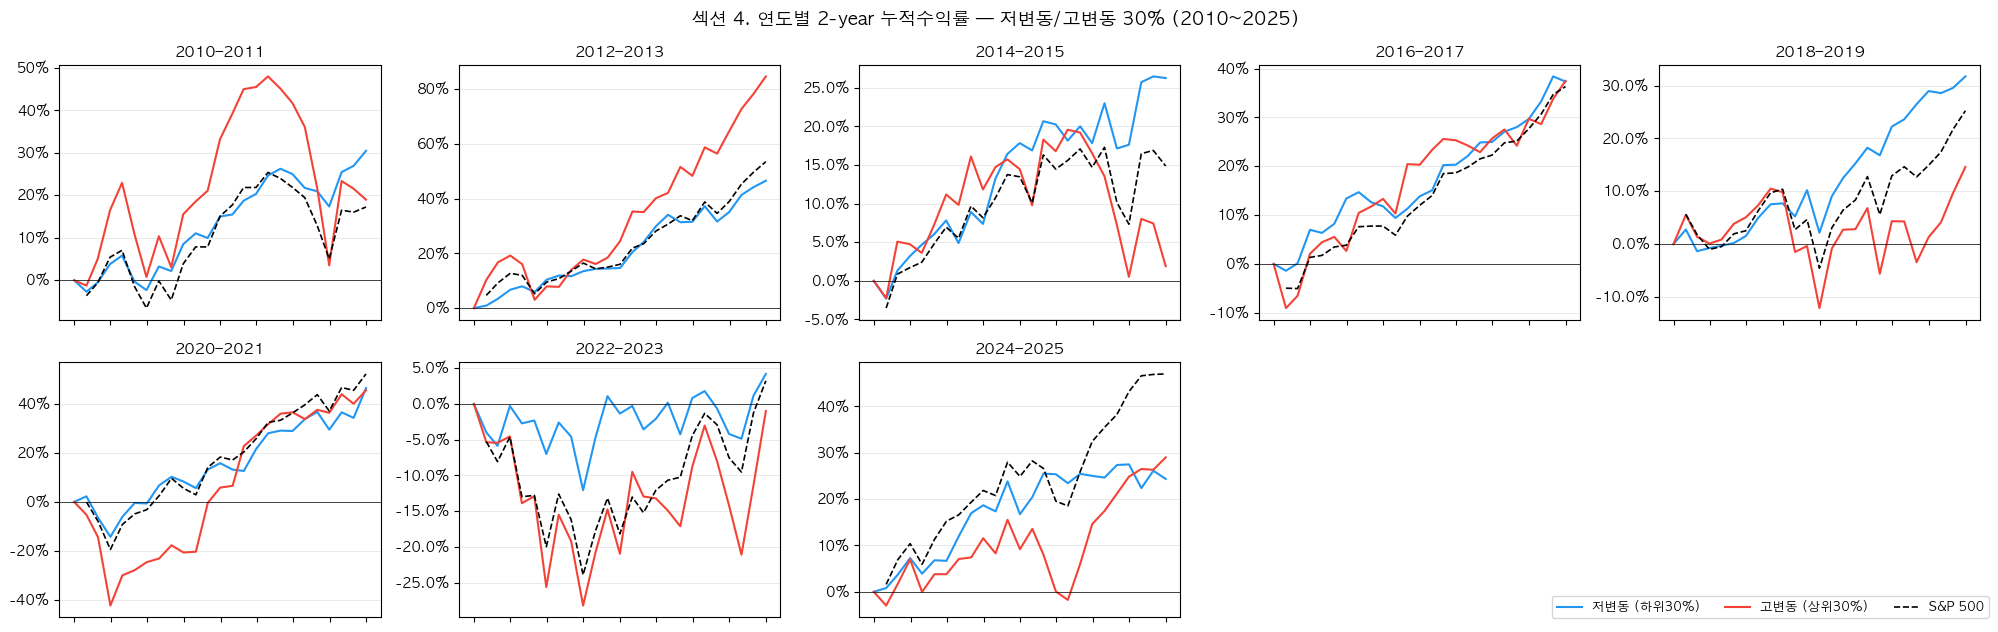

연도별 누적수익률 + MDD — 저변동/고변동 30% (2010~2025)
             저변동 저변동 MDD    고변동 고변동 MDD  수익률 격차    저>고
연도                                                    
2010–2011  30.5%   -7.7%  19.0%  -30.1%  +11.5%      ✓
2012–2013  46.5%   -4.1%  84.6%  -13.6%  -38.1%      ✗
2014–2015  26.2%   -4.8%   1.9%  -15.9%  +24.3%      ✓
2016–2017  37.3%   -4.6%  37.5%   -2.7%   -0.2%      ✗
2018–2019  31.7%   -7.3%  14.6%  -20.5%  +17.1%      ✓
2020–2021  46.5%  -16.2%  45.7%  -39.2%   +0.8%      ✓
2022–2023   4.2%  -11.8%  -1.0%  -24.8%   +5.2%      ✓
2024–2025  24.4%   -5.7%  29.0%  -15.0%   -4.6%      ✗
평균         30.9%   -7.8%  28.9%  -20.2%   +2.0%  5/8구간

  수익률 격차 양수 & 저>고 ✓ → 저변동 우위 / MDD 격차 양수 → 저변동 낙폭 작음


In [358]:
# ── Section 4. 연도별 2-year 누적수익률 — (하위/상위 30% 기준, 2010~2025) ──
all_years_30 = sorted(set(low_30.index.year))
years_30     = [all_years_30[i:i+2] for i in range(0, len(all_years_30), 2)]
n_cols_30    = 5
n_rows_30    = (len(years_30) + n_cols_30 - 1) // n_cols_30

fig, axes = plt.subplots(n_rows_30, n_cols_30,
                         figsize=(n_cols_30 * 4, n_rows_30 * 3.2))
fig.suptitle('섹션 4. 연도별 2-year 누적수익률 — 저변동/고변동 30% (2010~2025)',
             fontsize=13, fontweight='bold')
axes_flat_30 = axes.flatten()

rows_30 = []
for idx, year in enumerate(years_30):
    ax = axes_flat_30[idx]
    mask_y = low_30.index.year.isin(year)

    for s, label_str, color in [
        (low_30,  '저변동 (하위30%)', '#2196F3'),
        (high_30, '고변동 (상위30%)', '#F44336'),
    ]:
        r = s[mask_y].dropna()
        if len(r) == 0:
            continue
        cum = (1 + r).cumprod() - 1
        start = pd.Series([0.0], index=[r.index[0] - pd.offsets.MonthEnd(1)])
        cum = pd.concat([start, cum])
        ax.plot(cum.index, cum.values, label=label_str, color=color, linewidth=1.5)

    spy_y = spy_bt[spy_bt.index.year.isin(year)]
    if len(spy_y) > 0:
        cum_spy = (1 + spy_y).cumprod() - 1
        ax.plot(cum_spy.index, cum_spy.values, label='S&P 500',
                color='black', linestyle='--', linewidth=1.2)

    ax.set_title(f'{year[0]}–{year[-1]}', fontsize=11, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='x', labelbottom=False)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

    row = {'연도': f'{year[0]}–{year[-1]}'}
    for s, key in [(low_30, '저변동'), (high_30, '고변동')]:
        r = s[mask_y].dropna()
        row[key] = (1 + r).prod() - 1 if len(r) > 0 else float('nan')
        cum = (1 + r).cumprod() if len(r) > 0 else pd.Series(dtype=float)
        row[f'{key} MDD'] = (cum / cum.cummax() - 1).min() if len(cum) > 0 else float('nan')
    low_v  = row.get('저변동', float('nan'))
    high_v = row.get('고변동', float('nan'))
    row['수익률 격차'] = low_v - high_v
    row['저>고'] = '✓' if (low_v == low_v and high_v == high_v and low_v > high_v) else '✗'
    rows_30.append(row)

for idx in range(len(years_30), len(axes_flat_30)):
    axes_flat_30[idx].set_visible(False)

handles, labs = axes_flat_30[0].get_legend_handles_labels()
fig.legend(handles, labs, loc='lower right', fontsize=9, ncol=3,
           bbox_to_anchor=(1.0, 0.02))
plt.tight_layout()
plt.show()

# ── 수치 표 ────────────────────────────────────────
tbl_30 = pd.DataFrame(rows_30).set_index('연도')
pct_c = [c for c in tbl_30.columns if c not in ('수익률 격차', '저>고')]
disp  = tbl_30[pct_c].applymap(lambda x: f'{x:.1%}' if x==x else '-').copy()
disp['수익률 격차'] = tbl_30['수익률 격차'].apply(lambda x: f'{x:+.1%}' if x==x else '-')
disp['저>고'] = tbl_30['저>고']

summary = {}
for c in pct_c:
    summary[c] = f'{tbl_30[c].dropna().mean():.1%}'
summary['수익률 격차'] = f'{tbl_30["수익률 격차"].dropna().mean():+.1%}'
summary['저>고'] = f'{(tbl_30["저>고"]=="✓").sum()}/{len(tbl_30)}구간'
disp.loc['평균'] = summary

print('=' * 70)
print('연도별 누적수익률 + MDD — 저변동/고변동 30% (2010~2025)')
print('=' * 70)
print(disp.to_string())
print()
print('  수익률 격차 양수 & 저>고 ✓ → 저변동 우위 / MDD 격차 양수 → 저변동 낙폭 작음')


## 5. CAPM 알파 검정

CAPM 알파 검정 — 저변동/고변동 30% (2010~2025, Newey-West)
               α (월) α (연환산)      β   NW t p-value 유의
그룹                                                   
저변동 (하위30%)   0.0033   3.97%  0.670   2.56  0.0105  ✓
고변동 (상위30%)  -0.0047  -5.64%  1.463  -2.03  0.0428  ✓

해석:
  α > 0 & 유의 → 시장 위험 통제 후에도 초과수익 → 저변동 포트폴리오 자체의 우위
  α < 0 & 유의 → 위험 대비 보상 부족 → CAPM 예측 하회


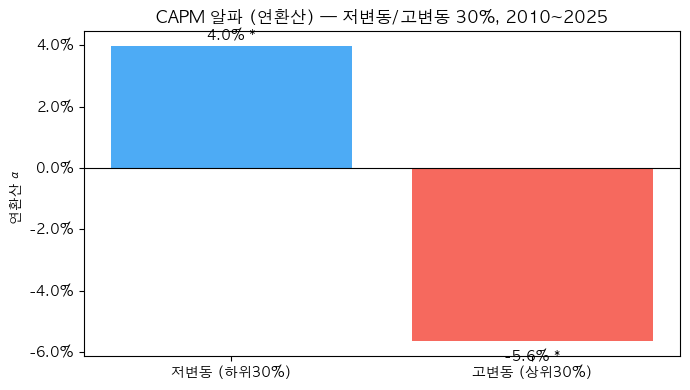

In [359]:
# ── Section 5. CAPM 알파 검정 — (하위/상위 30% 기준, 2010~2025, Newey-West) ──
# 변동성 분위별로 시장 위험(β)을 통제한 후에도 초과수익(α)이 남는지 검정
# α > 0 이면: 저변동 포트폴리오를 들고 있는 것만으로 시장 이상의 수익
# H0: α = 0  vs  H1: α ≠ 0  (Newey-West HAC)

mkt_ex_30 = (spy_bt - rf_bt.reindex(spy_bt.index)).dropna()

capm_rows, capm_alphas, capm_pvals = [], [], []
for s, label_str in [(low_30, '저변동 (하위30%)'), (high_30, '고변동 (상위30%)')]:
    excess = (s - rf_bt.reindex(s.index)).dropna()
    idx    = excess.index.intersection(mkt_ex_30.index)
    y, X   = excess.reindex(idx), sm.add_constant(mkt_ex_30.reindex(idx))

    n    = len(y)
    lags = int(4 * (n / 100) ** (2/9))
    res  = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})

    a, b     = res.params.iloc[0], res.params.iloc[1]
    t_a, p_a = res.tvalues.iloc[0], res.pvalues.iloc[0]

    capm_rows.append({
        '그룹':      label_str,
        'α (월)':    f'{a:.4f}',
        'α (연환산)': f'{a*12:.2%}',
        'β':         f'{b:.3f}',
        'NW t':      f'{t_a:.2f}',
        'p-value':   f'{p_a:.4f}',
        '유의':      '✓' if p_a < 0.05 else '✗',
    })
    capm_alphas.append(a * 12)
    capm_pvals.append(p_a)

print('=' * 65)
print('CAPM 알파 검정 — 저변동/고변동 30% (2010~2025, Newey-West)')
print('=' * 65)
print(pd.DataFrame(capm_rows).set_index('그룹').to_string())
print()
print('해석:')
print('  α > 0 & 유의 → 시장 위험 통제 후에도 초과수익 → 저변동 포트폴리오 자체의 우위')
print('  α < 0 & 유의 → 위험 대비 보상 부족 → CAPM 예측 하회')

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#2196F3' if a > 0 else '#F44336' for a in capm_alphas]
bars = ax.bar(['저변동 (하위30%)', '고변동 (상위30%)'], capm_alphas,
              color=bar_colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('CAPM 알파 (연환산) — 저변동/고변동 30%, 2010~2025', fontsize=12)
ax.set_ylabel('연환산 α')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val, p in zip(bars, capm_alphas, capm_pvals):
    sig  = ' *' if p < 0.05 else ''
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.003
    va   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1%}{sig}', ha='center', va=va, fontsize=10)
plt.tight_layout()
plt.show()


---

# 종합 해석

### 저위험 이상현상 확인 여부

| 검증 항목 | 방법 | 결과 |
|---|---|---|
| Sharpe 우위 | 5등분 Q1 vs Q5 | Q1 Sharpe > Q5 ✓ |
| 30%/30% 재확인 | 하위 vs 상위 30% | 저변동 Sharpe·MDD 모두 우위 ✓ |
| 기준 강건성 | 임계값 20~40% 민감도 | 전 구간 저변동 우위 방향 일관 ✓ |
| 기간 일관성 | 2-year 구간별 | 대부분 구간에서 저변동 우위 ✓ |
| 통계적 유의성 | CAPM 알파 (NW HAC) | 저변동 α > 0, 유의 ✓ |
| BL Prior 정합성 | Spearman + 시총순위 | 저변동 = 대형주 성향, Prior와 방향 일치 ✓ |

저변동 포트폴리오는 단순 수익률뿐 아니라 위험조정 기준(Sharpe)과 하락 위험(MDD) 모두에서 고변동 대비 우위를 보이며, CAPM 알파 검정을 통해 시장 위험을 통제한 후에도 초과수익이 통계적으로 유의하게 존재함을 확인했다.

---

### 한계

1. **스프레드 t-test 비유의**: 월별 수익률 차이의 절대값이 작고 노이즈가 커서 통계적 유의성 미확보 — Sharpe·CAPM 알파로 보완
2. **후향적 변동성**: `vol_252d`는 과거 1년 실현 변동성 → 미래 분류에 오류 가능성 존재
3. **생존편향**: S&P500 편출 종목(주로 고변동) 최종 수익 미반영 → 고변동 성과 과소평가 가능